# SOSSA SDP and sparse resource-estimate workflow

This notebook demonstrates how to use the merged `ResourceEstimates` class from `SOSSA_resource_estimates.py` to:

1. build molecular one- and two-electron integrals with PySCF,
2. solve the SOS semidefinite program (SDP),
3. extract the SOS normalization, SOS energy, SDP rank, and generator-coefficient sparse support, and
4. use that sparse support to estimate Toffoli and logical-qubit resources.

The important design point is that the same object does both jobs. First, `solver.solve()` solves the SDP and stores the result internally. Then, `solver.estimate_resources(...)` uses the most recent successful SDP solution by default, including `Lambda`, `E_SOS`, `R`, and `d_sparse`.

## Imports

The class is imported as `est` for convenience:

```python
from SOSSA_resource_estimates import ResourceEstimates as est
```

`ResourceEstimates` needs `numpy` and `cvxpy` internally. PySCF is used here only to generate molecular integrals and run the SCF calculation. The plots at the end use `matplotlib`.

In [1]:
from SOSSA_resource_estimates import ResourceEstimates as est
import numpy as np
import cvxpy as cp
from pyscf import gto, scf, ao2mo
import matplotlib.pyplot as plt

## Optional notebook export

The `nbconvert` command below exports the notebook to a plain Python script. This is optional; it is useful when you want a `.py` copy of the workflow for batch runs or version control.

In [2]:
!jupyter nbconvert test_run_SOSSA.ipynb --to python

[NbConvertApp] Converting notebook test_run_SOSSA.ipynb to python
[NbConvertApp] Writing 14772 bytes to test_run_SOSSA.py


## Molecular test set and basis choice

This cell defines a small set of molecules and geometries, chooses the `sto-3g` basis, and sorts the molecules by increasing number of atomic orbitals. Sorting by basis size is useful because the SOS SDP grows quickly with the number of spatial orbitals.

In this notebook:

- `nao` is the number of spatial molecular orbitals after the AO-to-MO transformation.
- `M_spin = 2 * nao` is the number of spin-orbitals used by the resource-estimate formulas.
- `spin = 0` selects RHF; nonzero spin selects ROHF so that a common spatial-orbital basis is retained.

In [3]:
basis = "sto-3g"
epsilon = 1.5e-3  # PEA accuracy threshold in Hartree

# --- Bond lengths / angles (Angstrom / degrees) ---
R_OO_O3   = 1.278
ANG_OOO   = 116.8

R_NO_NO2  = 1.20
ANG_ONO   = 134.0

R_NN_N2O  = 1.12
R_NO_N2O  = 1.19

R_CO_CH3OH = 1.43
R_OH       = 0.96
R_CH       = 1.09
a_CH       = R_CH / np.sqrt(3.0)

R_CCl_CH3Cl = 1.78

# --- Geometry helpers ---
x_o3 = R_OO_O3 * np.sin(np.radians(ANG_OOO / 2.0))
z_o3 = R_OO_O3 * np.cos(np.radians(ANG_OOO / 2.0))

x_no2 = R_NO_NO2 * np.sin(np.radians(ANG_ONO / 2.0))
z_no2 = R_NO_NO2 * np.cos(np.radians(ANG_ONO / 2.0))

names = ["O3", "NO2", "N2O", "CH3OH", "CH3Cl"]

molecules = [
    f"""
    O  0.000000  0.000000   0.000000
    O  {+x_o3:.6f}  0.000000  {+z_o3:.6f}
    O  {-x_o3:.6f}  0.000000  {+z_o3:.6f}
    """,

    f"""
    N  0.000000  0.000000   0.000000
    O  {+x_no2:.6f}  0.000000  {+z_no2:.6f}
    O  {-x_no2:.6f}  0.000000  {+z_no2:.6f}
    """,

    f"""
    N  0.000000  0.000000  {-R_NN_N2O:.6f}
    N  0.000000  0.000000   0.000000
    O  0.000000  0.000000   {R_NO_N2O:.6f}
    """,

    f"""
    C  0.000000  0.000000   0.000000
    O  0.000000  0.000000   {R_CO_CH3OH:.6f}
    H  0.000000  0.000000   {R_CO_CH3OH + R_OH:.6f}
    H  {+a_CH:.6f}  {+a_CH:.6f}  {+a_CH:.6f}
    H  {-a_CH:.6f}  {-a_CH:.6f}  {+a_CH:.6f}
    H  {-a_CH:.6f}  {+a_CH:.6f}  {-a_CH:.6f}
    """,

    f"""
    C   0.000000  0.000000   0.000000
    Cl  0.000000  0.000000   {R_CCl_CH3Cl:.6f}
    H   {+a_CH:.6f}  {+a_CH:.6f}  {+a_CH:.6f}
    H   {-a_CH:.6f}  {-a_CH:.6f}  {+a_CH:.6f}
    H   {-a_CH:.6f}  {+a_CH:.6f}  {-a_CH:.6f}
    """
]

charges = [0, 0, 0, 0, 0]
spins   = [0, 1, 0, 0, 0]  # NO2 is doublet

assert len(names) == len(molecules) == len(charges) == len(spins) == 5


def count_nao(geom, charge, spin, basis=basis):
    mol = gto.M(
        atom=geom,
        unit="Angstrom",
        basis=basis,
        charge=charge,
        spin=spin,
        verbose=0,
    )
    return getattr(mol, "nao", mol.nao_nr())


# --- Sort by increasing NAO ---
records = []
for name, geom, q, s in zip(names, molecules, charges, spins):
    nao = count_nao(geom, q, s, basis=basis)
    records.append((nao, name, geom, q, s))

records.sort(key=lambda t: (t[0], t[1]))

print("Order by increasing basis size (STO-3G NAO):")
for nao, name, *_ in records:
    print(f"{name:6s}  nao = {nao}")

names     = [name for (nao, name, geom, q, s) in records]
molecules = [geom  for (nao, name, geom, q, s) in records]
charges   = [q     for (nao, name, geom, q, s) in records]
spins     = [s     for (nao, name, geom, q, s) in records]

Order by increasing basis size (STO-3G NAO):
CH3OH   nao = 14
N2O     nao = 15
NO2     nao = 15
O3      nao = 15
CH3Cl   nao = 17


## Main SOSSA loop

For each molecule, this cell performs four steps.

### 1. Build molecular integrals

PySCF constructs the molecule and computes the AO one-electron core Hamiltonian,

```python
hcore_ao = T + V_nuc,
```

then SCF is run with RHF for closed-shell systems and ROHF for open-shell systems. The MO coefficient matrix `C` is used to transform the one-electron integrals into the MO basis:

```python
h1_mo = C.T @ hcore_ao @ C
```

The two-electron integrals are also transformed into the MO basis using `ao2mo.kernel` and restored to a four-index tensor `h2_mo`.

### 2. Solve the SOS SDP

The merged class is instantiated as:

```python
solver = est(norb=nao, h1=h1_mo, h2=h2_mo, ...)
```

Here `norb=nao` means the SDP side of the class receives the number of spatial orbitals. The resource side later receives the number of spin-orbitals through `M_spin_orbitals=M_spin`.

The call

```python
out = solver.solve()
```

solves the SDP and returns a dictionary containing:

- `out["Lambda"]`: the SOS block-encoding normalization,
- `out["ESOS"]`: the optimized SOS energy,
- `out["total_rank"]`: the total number of SOS factors from the PSD factorizations,
- `out["sos_support"]["d_sparse"]`: sparse support counted from generator coefficients,
- `out["diagnostics"]`: solver status, ranks, residual checks, and dropped G10 rows.

### 3. Compute sparse support

The sparse support is not guessed from the dense integral tensor. After the SDP solve, the PSD matrices are factorized into lowercase generator coefficients `g`, `gbar`, `d`, and `q`. The class thresholds those coefficient arrays and counts their nonzero entries:

```python
d_sparse = nnz(g) + nnz(gbar) + nnz(d) + nnz(q)
```

The threshold is controlled by `support_threshold=1e-5` in this notebook. Smaller values count more small coefficients as nonzero; larger values give a more aggressively sparse estimate.

### 4. Estimate resources from the same object

After a successful solve, the resource call is:

```python
resource_summary = solver.estimate_resources(
    E_0=E_hf,
    eps_qpe=eps_qpe,
    M_spin_orbitals=M_spin,
    bits_precision=bits_precision,
    ...
)
```

By default, `estimate_resources()` uses the most recent successful `solve()` result. That means `Lambda`, `E_SOS`, `R`, and `d_sparse` are pulled automatically from `out` unless you explicitly override them.

When `d_sparse` is available, the resource model uses

```python
table_size = d_sparse
```

instead of the dense fallback

```python
table_size = R * L_dense
```

Therefore `total_toffoli` and `logical_qubits` in `resource_summary` are sparse-support-based. The SELECT cost is still modeled as an `O(M_spin_orbitals)` proxy, but the QROM/PREPARE table size and QROAM optimization use the sparse support.

A useful sanity check is:

```python
assert resource_summary["using_generator_coefficient_d_sparse"] is True
assert resource_summary["table_size"] == out["sos_support"]["d_sparse"]
```

In [4]:
# ---------------------------------------------------------------------
# Build integrals, run SCF,
# solve SOS SDP, compute sparse support,
# and compute SOSSA resource estimates
# ---------------------------------------------------------------------

energies = []
h1_list = []
h2_list = []
naos = []
N_list = []  # spin-orbitals = 2 * nao

# SOSSA SDP data
lambda_list = []
E_SOS_list = []
R_list = []
d_sparse_list = []
support_list = []

# SOSSA resource-estimate data
total_toffoli_list = []
logical_qubits_list = []
resource_summary_list = []

eps_qpe = 1e-3  # In units of Hartree
bits_precision = 10  # Standard choice in the literature

for name, mol_geom, charge, spin in zip(names, molecules, charges, spins):
    mol = gto.M(
        atom=mol_geom,
        unit="Angstrom",
        basis=basis,
        charge=charge,
        spin=spin,
        verbose=0,
    )

    nao = getattr(mol, "nao", mol.nao_nr())
    naos.append(nao)

    M_spin = 2 * nao
    N_list.append(M_spin)

    # AO one-electron integrals
    hcore_ao = mol.intor("int1e_kin") + mol.intor("int1e_nuc")

    # RHF for singlets, ROHF for open-shell systems so we retain one common
    # spatial-orbital basis for alpha/beta spins.
    mf = scf.RHF(mol) if spin == 0 else scf.ROHF(mol)
    mf.conv_tol = 1e-10
    E_hf = mf.kernel()
    energies.append(E_hf)

    # MO coefficients
    C = mf.mo_coeff

    # One-electron integrals in MO basis
    h1_mo = C.T @ hcore_ao @ C

    # Two-electron integrals in MO basis, chemist notation (pq|rs)
    eri_mo = ao2mo.kernel(mol, C)
    h2_mo = ao2mo.restore(1, eri_mo, nao)

    h1_list.append(h1_mo)
    h2_list.append(h2_mo)

    # --------------------------------------------------------------
    # SOSSA SDP solve + generator-coefficient sparse support estimate
    # --------------------------------------------------------------
    solver = est(
        norb=nao,
        h1=h1_mo,
        h2=h2_mo,
        spin_explicit=False,
        enforce_spin_free=True,
        use_triu_pairs=True,
        h2_abs_threshold=1e-6,
        support_threshold=1e-5,
        solver="SCS",
        max_iterations=200000,
        verbose=False,
    )

    out = solver.solve()

    if out["diagnostics"]["status"] not in ("optimal", "optimal_inaccurate"):
        print(f"{name}: SOSSA SDP failed with status {out['diagnostics']['status']}")
        lambda_list.append(np.nan)
        E_SOS_list.append(np.nan)
        R_list.append(0)
        d_sparse_list.append(0)
        support_list.append(None)
        total_toffoli_list.append(np.nan)
        logical_qubits_list.append(np.nan)
        resource_summary_list.append(None)
        continue

    lambda_list.append(out["Lambda"])
    E_SOS_list.append(out["ESOS"])
    R_list.append(out["total_rank"])
    d_sparse_list.append(out["sos_support"]["d_sparse"])
    support_list.append(out["sos_support"])

    # --------------------------------------------------------------
    # SOSSA resource estimates
    #
    # estimate_resources() uses Lambda, E_SOS, R, and d_sparse from the most
    # recent successful solve(), unless explicitly overridden.
    #
    # E_0 is taken here to be the SCF/HF energy. Replace this with a better
    # reference energy if you have one.
    # --------------------------------------------------------------
    resource_summary = solver.estimate_resources(
        E_0=E_hf,
        eps_qpe=eps_qpe,
        M_spin_orbitals=M_spin,
        bits_precision=bits_precision,
        optimum=True,
        reduced_diagonal_doublets=True,
        real_coefficients=True,
        include_a16_overheads=True,
        include_qpe_qubits=True,
    )

    resource_summary_list.append(resource_summary)

    total_toffoli_list.append(resource_summary["total_toffoli"])
    logical_qubits_list.append(resource_summary["logical_qubits"])

    print(f"Molecule: {name} is done")
    print(f"Solution status: {out['diagnostics']['status']}")

Molecule: CH3OH is done
Solution status: optimal
Molecule: N2O is done
Solution status: optimal
Molecule: NO2 is done
Solution status: optimal
Molecule: O3 is done
Solution status: optimal
Molecule: CH3Cl is done
Solution status: optimal


## Fractional SOS energy gap plot

This plot compares the optimized SOS energy against the SCF/HF energy for each molecule. It is a diagnostic plot, not a resource estimate. Large deviations may indicate that the SDP settings, basis, solver tolerance, or reference energy choice should be revisited.

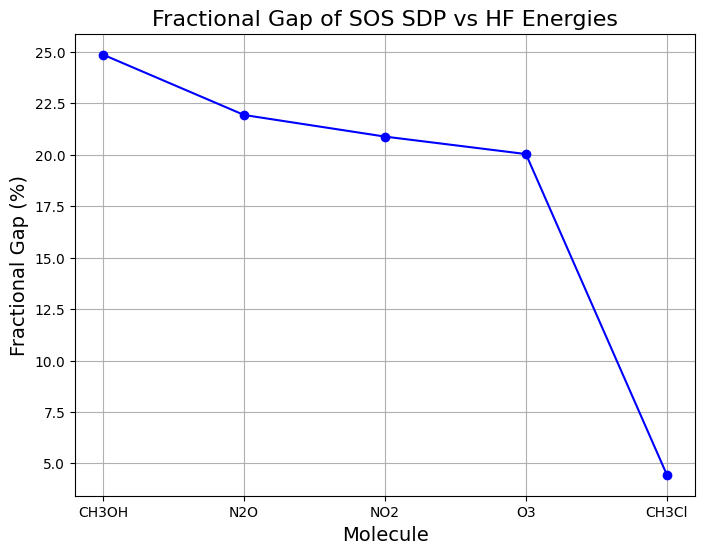

In [5]:
frac_gap_list = []
for E_scf, E_sos in zip(energies, E_SOS_list):
    frac_gap = np.abs((np.abs(E_scf)-E_sos)/E_scf)*100
    frac_gap_list.append(frac_gap)  # percentage error
plt.figure(figsize=(8,6))
plt.plot(names, frac_gap_list, marker='o', linestyle='-', color='b')
plt.xlabel('Molecule', fontsize=14)
plt.ylabel('Fractional Gap (%)', fontsize=14)
plt.title('Fractional Gap of SOS SDP vs HF Energies', fontsize=16)
plt.grid(True)
plt.show()

## Toffoli-count plot

`total_toffoli_list` is populated from:

```python
resource_summary["total_toffoli"]
```

This total is computed as:

```python
num_walk_steps * walk_toffoli
```

where `num_walk_steps` depends on `Lambda`, `E_SOS`, `E_0`, and `eps_qpe`, and `walk_toffoli` includes the block-encoding and walk-reflection costs. Because the block-encoding table size is `d_sparse`, this plot reflects the generator-coefficient sparse-support model.

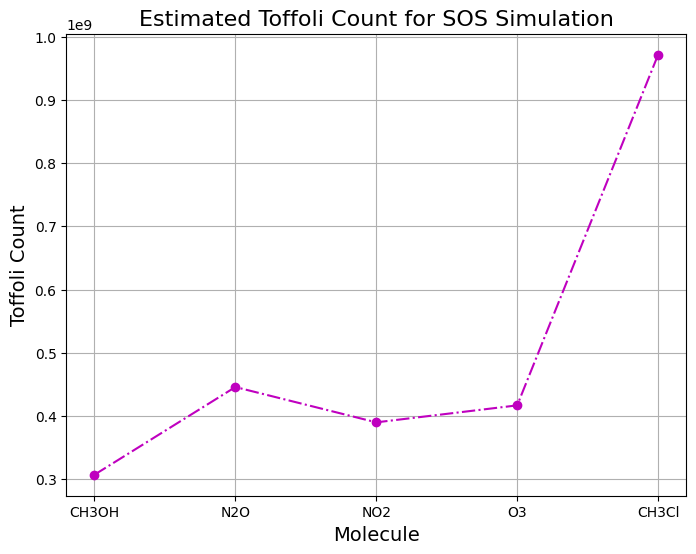

In [6]:
plt.figure(figsize=(8,6))
plt.plot(names, total_toffoli_list, marker='o', linestyle='-.', color='m')
plt.xlabel('Molecule', fontsize=14)
plt.ylabel('Toffoli Count', fontsize=14)
plt.title('Estimated Toffoli Count for SOS Simulation', fontsize=16)
plt.grid(True)
plt.show()

## Logical-qubit plot

`logical_qubits_list` is populated from:

```python
resource_summary["logical_qubits"]
```

The logical-qubit estimate includes spin-orbital registers, QPE qubits if enabled, PREPARE address bits, precision registers, QROM workspace, and small fixed overheads. The QROM workspace and PREPARE address width depend on the sparse table size when `d_sparse` is available.

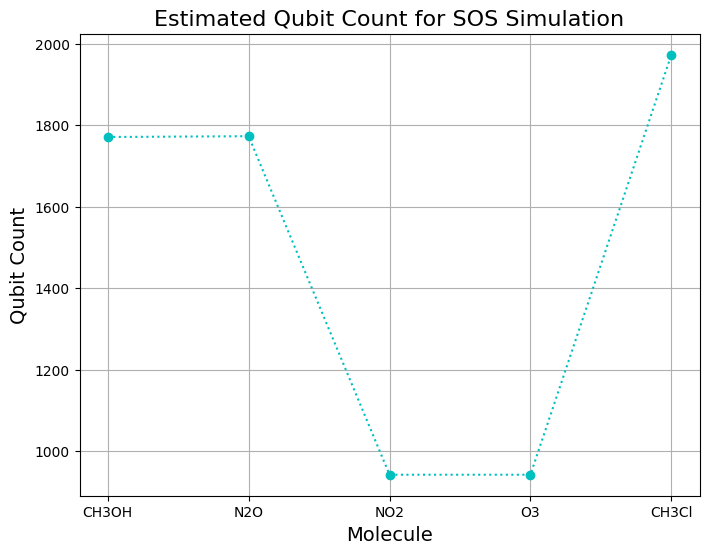

In [7]:
plt.figure(figsize=(8,6))
plt.plot(names, logical_qubits_list, marker='o', linestyle=':', color='c')
plt.xlabel('Molecule', fontsize=14)
plt.ylabel('Qubit Count', fontsize=14)
plt.title('Estimated Qubit Count for SOS Simulation', fontsize=16)
plt.grid(True)
plt.show()

## What to inspect after a run

After the loop finishes, `resource_summary_list` contains one dictionary per molecule. Useful keys include:

```python
resource_summary_list[i]["d_sparse"]
resource_summary_list[i]["table_size"]
resource_summary_list[i]["chosen_k"]
resource_summary_list[i]["qrom_output_bits"]
resource_summary_list[i]["num_walk_steps"]
resource_summary_list[i]["total_toffoli"]
resource_summary_list[i]["logical_qubits"]
```

For debugging sparsity, inspect `support_list[i]`, which contains the individual nonzero counts for `g`, `gbar`, `d`, and `q`.